# Load weather data from open-meteo with API request

## Steps
* get the latitude and longitude of the selected cities
* construct the request, with header information with paramaters including the latitude and longitude of the selected cities, start and end date time, hourly, the variables below 


### variables
* `temperature_2m`
* `apparent_temperature`
* `precipitation`
* `rain`
* `snowfall`
* `wind_speed_10m`
* `shortwave_radiation`

### selected cities 
	Berlin, Hamburg, München, Köln, Frankfurt


##  read weather data of the selected cities from 2019-01-01 till 2025-09-30 (time range of the electricity load file) over open-meteo archive-api

In [ ]:
import requests
import pandas as pd 

#url_open_meteo_history = 'https://open-meteo.com/en/docs/historical-weather-api'
#url_open_meteo = "https://archive-api.open-meteo.com/v1/archive?latitude=51.1657&longitude=10.4515&start_date=2019-01-01&end_date=2025-12-31&hourly=temperature_2m,precipitation_sum,windspeed_10m,winddirection_10m,weathercode&timezone=auto"

# contrust request URL for historical weather data for Germany (latitude: 51.1657, longitude: 10.4515) from January 1, 2019 to January 2, 2019 with hourly data for temperature_2m, apparent_temperature, precipitation, rain, snowfall, wind_speed_10m, and shortwave_radiation, weathercode and timezone set to auto
url_open_meteo_de_1d = "https://archive-api.open-meteo.com/v1/archive?latitude=51.1657&longitude=10.4515&start_date=2019-01-01&end_date=2019-01-02&hourly=temperature_2m,apparent_temperature,precipitation,rain,snowfall,wind_speed_10m,shortwave_radiation,weathercode&timezone=auto"

response = requests.get(url_open_meteo_de_1d)
weather_data_de_1d = response.json()



,latitude,longitude,generationtime_ms,utc_offset_seconds,timezone,timezone_abbreviation,elevation,hourly_units,hourly
0,51.142353,10.502693,280.411601,7200,Europe/Berlin,GMT+2,203.0,NaN,NaN


## create dataframe with the hourly field from response including the weather data

In [11]:
df_weather_de_1d = pd.DataFrame(weather_data_de_1d['hourly'])
df_weather_de_1d['time'] = pd.to_datetime(df_weather_de_1d['time'], utc=True)
display(df_weather_de_1d.head())

,time,temperature_2m,apparent_temperature,precipitation,rain,snowfall,wind_speed_10m,shortwave_radiation,weathercode
0,2019-01-01 00:00:00+00:00,6.0,2.8,0.0,0.0,0.0,13.9,0.0,3
1,2019-01-01 01:00:00+00:00,5.8,2.3,0.0,0.0,0.0,14.8,0.0,3
2,2019-01-01 02:00:00+00:00,6.4,3.3,0.0,0.0,0.0,14.3,0.0,3
3,2019-01-01 03:00:00+00:00,6.5,2.9,0.0,0.0,0.0,17.3,0.0,3
4,2019-01-01 04:00:00+00:00,6.2,2.3,0.0,0.0,0.0,18.9,0.0,3


##  read weather data of the selected cities from 2019-01-01 till 2025-09-30 (time range of the electricity load file) over open-meteo archive-api in a loop and save the dataframes to csv for later usage


In [1]:
import time
import requests
import pandas as pd 

# apparent_temperature is the perceived temperature, which takes into account factors such as humidity and wind speed to provide a more accurate representation of how the temperature feels to humans. It is calculated using a formula that combines the actual air temperature with the effects of humidity and wind chill. The apparent temperature can be higher than the actual temperature in hot and humid conditions, and lower than the actual temperature in cold and windy conditions.
# precipitation is the amount of water that falls from the atmosphere to the ground in the form of rain, snow, sleet, or hail. It is typically measured in millimeters (mm) or inches (in) and can be used to assess the amount of moisture in the air and the likelihood of certain weather conditions, such as flooding or drought.
# shortwave_radiation is the amount of solar radiation that reaches the Earth's surface in the form of shortwave electromagnetic waves. It is typically measured in watts per square meter (W/m²) and can be used to assess the amount of energy available for photosynthesis, as well as the potential for solar power generation.
# weathercode is a numerical code that represents the current weather conditions. It is typically used in weather forecasting and can be used to quickly identify the type of weather that is expected, such as clear skies, rain, snow, or thunderstorms.
weather_variables = ['temperature_2m', 'apparent_temperature', 'precipitation', 'rain', 'snowfall', 'wind_speed_10m', 'shortwave_radiation', 'weathercode']

# get latitude and longitude of German cities: Berlin, Hamburg, München, Köln, Frankfurt
selected_cities = {  
    'Berlin': {'latitude': 52.5200, 'longitude': 13.4050},
    'Hamburg': {'latitude': 53.5511, 'longitude': 9.9937},
    'München': {'latitude': 48.1351, 'longitude': 11.5820},
    'Köln': {'latitude': 50.9375, 'longitude': 6.9603},
    'Frankfurt': {'latitude': 50.1109, 'longitude': 8.6821}
}

start_date = "2019-01-01"
end_date = "2025-09-30"
for city, coords in selected_cities.items():
    url = f"https://archive-api.open-meteo.com/v1/archive?latitude={coords['latitude']}&longitude={coords['longitude']}&start_date={start_date}&end_date={end_date}&hourly={','.join(weather_variables)}&timezone=auto"
    response = requests.get(url)
    weather_data = response.json()
    df_weather_city = pd.DataFrame(weather_data['hourly'])
    df_weather_city['time'] = pd.to_datetime(df_weather_city['time'], utc=True)
    #display(df_weather_city.head(3))
    df_weather_city.to_csv(f"../data/weather_data_{city}.csv", index=False)
    print(f"Weather data for {city} loaded and saved")
    time.sleep(2)  # Sleep for 2 seconds to avoid hitting API rate limits

print("Weather data collection completed for all selected cities and years.")


Weather data for Berlin loaded and saved
Weather data for Hamburg loaded and saved
Weather data for München loaded and saved
Weather data for Köln loaded and saved
Weather data for Frankfurt loaded and saved
Weather data collection completed for all selected cities and years.


In [2]:
# aggregate weather data for all cities into a single DataFrame, each column contains mean value of the respective weather variable for all cities

df_weather_all = pd.DataFrame()

for city, coords in selected_cities.items():
    df_weather_city = pd.read_csv(f"../data/weather_data_{city}.csv")
    df_weather_city['city'] = city
    df_weather_all = pd.concat([df_weather_all, df_weather_city], ignore_index=True)

df_weather_all = df_weather_all.groupby('time')[weather_variables].mean().reset_index()  
display(df_weather_all.head(10))


,time,temperature_2m,apparent_temperature,precipitation,rain,snowfall,wind_speed_10m,shortwave_radiation,weathercode
0,2019-01-01 00:00:00+00:00,5.88,2.74,0.00,0.00,0.0,13.66,0.0,2.8
1,2019-01-01 01:00:00+00:00,5.86,2.72,0.00,0.00,0.0,14.04,0.0,3.0
2,2019-01-01 02:00:00+00:00,6.42,3.18,0.04,0.04,0.0,15.10,0.0,12.6
3,2019-01-01 03:00:00+00:00,6.28,2.78,0.02,0.02,0.0,16.46,0.0,12.6
4,2019-01-01 04:00:00+00:00,6.08,2.24,0.02,0.02,0.0,17.84,0.0,12.6
5,2019-01-01 05:00:00+00:00,5.78,1.54,0.00,0.00,0.0,19.72,0.0,3.0
6,2019-01-01 06:00:00+00:00,5.62,1.16,0.02,0.02,0.0,21.06,0.0,12.6
7,2019-01-01 07:00:00+00:00,5.62,1.08,0.08,0.08,0.0,21.44,0.0,31.8
8,2019-01-01 08:00:00+00:00,5.58,1.02,0.04,0.04,0.0,21.34,0.0,12.6
9,2019-01-01 09:00:00+00:00,5.60,1.12,0.06,0.06,0.0,21.16,0.0,22.2


In [18]:
df_weather_all.describe()

,temperature_2m,apparent_temperature,precipitation,rain,snowfall,wind_speed_10m,shortwave_radiation,weathercode
count,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000
mean,11.650489,9.486594,0.085160,0.082132,0.002122,10.777534,137.789174,10.536094
std,8.013264,9.328194,0.368596,0.363546,0.036213,6.040792,212.174222,19.530113
min,-10.400000,-16.300000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.400000,2.100000,0.000000,0.000000,0.000000,6.400000,0.000000,1.000000
50%,11.100000,8.600000,0.000000,0.000000,0.000000,9.700000,6.000000,3.000000
75%,17.500000,16.500000,0.000000,0.000000,0.000000,14.100000,213.000000,3.000000
max,39.300000,40.200000,15.400000,15.400000,3.640000,48.200000,906.000000,75.000000


In [3]:
df_weather_all.isna().sum()

time                    0
temperature_2m          0
apparent_temperature    0
precipitation           0
rain                    0
snowfall                0
wind_speed_10m          0
shortwave_radiation     0
weathercode             0
dtype: int64

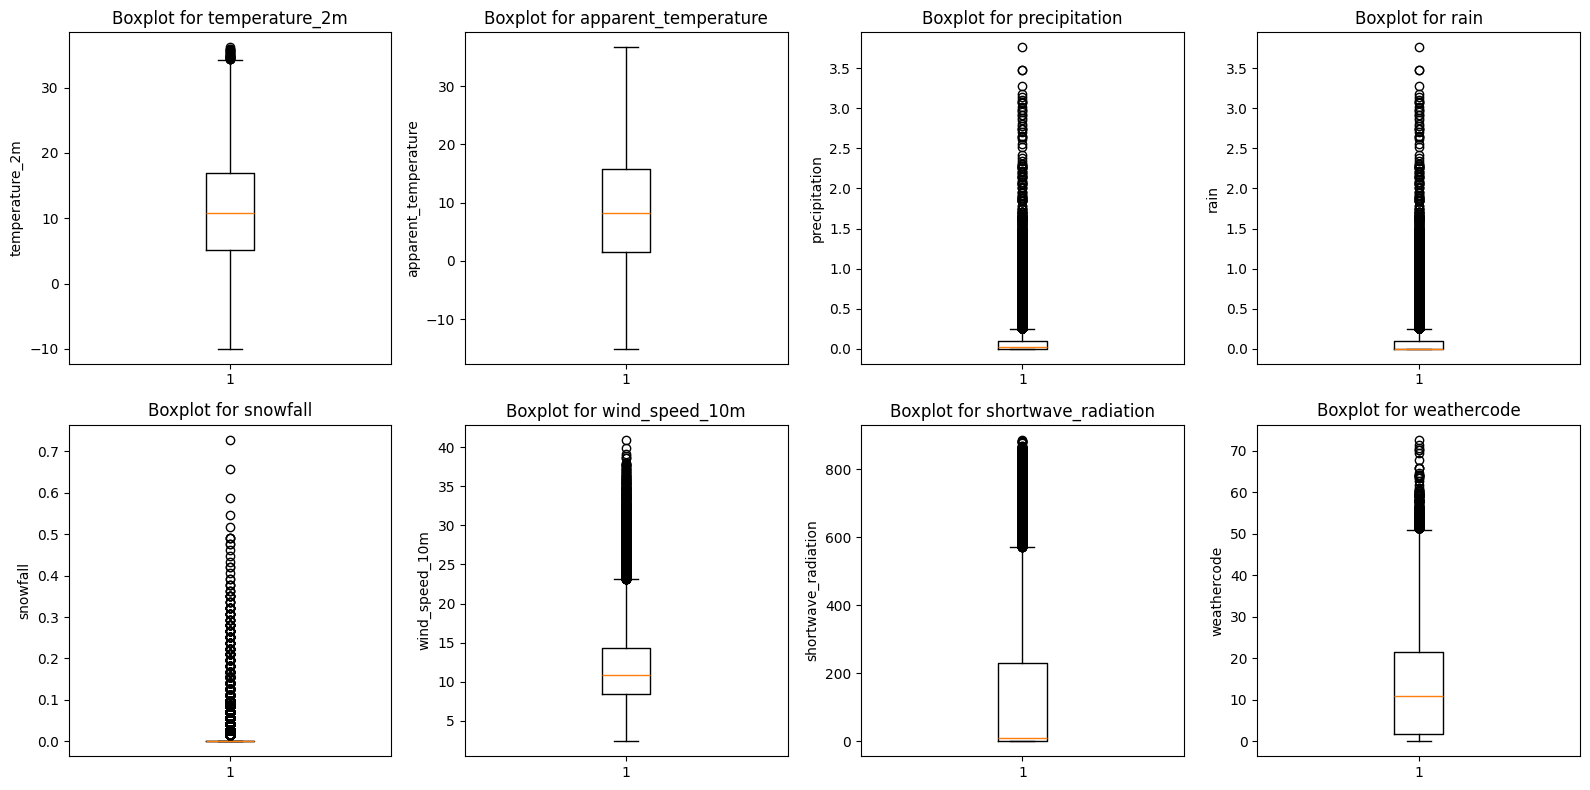

In [4]:
# check outliers in the weather data using boxplots for each weather variable
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 4, figsize=(16, 8))
ax = ax.flatten()

for i, variable in enumerate(weather_variables): 
    ax[i].boxplot(df_weather_all[variable])
    ax[i].set_title(f'Boxplot for {variable}')
    ax[i].set_ylabel(variable)
fig.tight_layout()
plt.show()

In [12]:
df_weather_all = df_weather_all.drop('weathercode', axis=1)

Text(0.5, 1.0, 'Correlation Heatmap of Weather Variables')

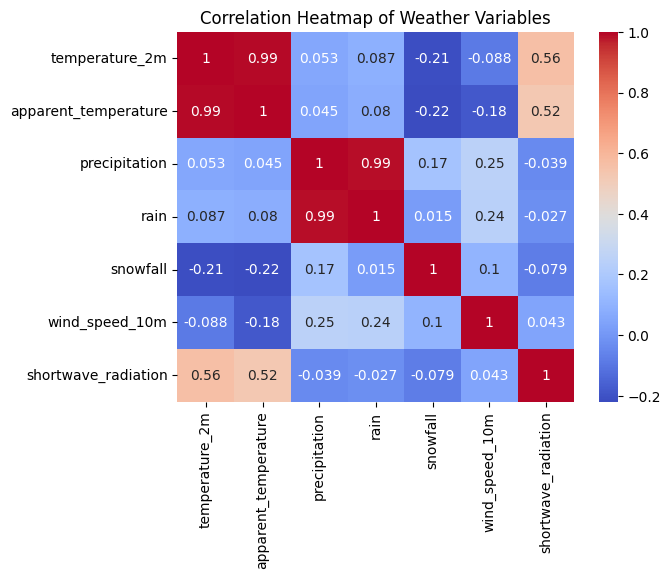

In [ ]:
import seaborn as sns

weather_corr = df_weather_all.drop('time', axis=1).corr()
sns.heatmap(weather_corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Weather Variables') 


In [13]:
df_weather_all
df_weather_all = df_weather_all.drop(columns=['precipitation', 'temperature_2m'], axis=1)
df_weather_all = df_weather_all.rename(columns={'time':"DateUTC"})
df_weather_all.head()

,DateUTC,apparent_temperature,rain,snowfall,wind_speed_10m,shortwave_radiation
0,2019-01-01 00:00:00+00:00,2.74,0.00,0.0,13.66,0.0
1,2019-01-01 01:00:00+00:00,2.72,0.00,0.0,14.04,0.0
2,2019-01-01 02:00:00+00:00,3.18,0.04,0.0,15.10,0.0
3,2019-01-01 03:00:00+00:00,2.78,0.02,0.0,16.46,0.0
4,2019-01-01 04:00:00+00:00,2.24,0.02,0.0,17.84,0.0


In [15]:
df_weather_all.to_csv("../data/weather_data_mean_cities_2019_2025.csv", index=False)